In [33]:
from google.colab import drive
drive.mount('/content/drive')


%cd /content/drive/MyDrive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive


In [34]:
!git clone https://github.com/VenuriDampahalage/ames-housing-price-prediction.git


fatal: destination path 'ames-housing-price-prediction' already exists and is not an empty directory.


In [35]:
%cd ames-housing-price-prediction

/content/drive/MyDrive/ames-housing-price-prediction


In [36]:
!git checkout -b feature/model-Evaluation

Switched to a new branch 'feature/model-Evaluation'


In [37]:
!git pull origin main

From https://github.com/VenuriDampahalage/ames-housing-price-prediction
 * branch            main       -> FETCH_HEAD
Already up to date.


In [38]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 3.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 51.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 64.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 13.1 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 57.8 MB/s eta 0:00:00:00:0100:01
   ━

In [39]:
!git status

On branch feature/model-Evaluation
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/best_model.joblib

nothing added to commit but untracked files present (use "git add" to track)


In [41]:
#import libraries
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
# load test data
X_test = pd.read_csv('data-new/X_test_preprocessed.csv')
y_test_log = pd.read_csv('data-new/y_test.csv').squeeze()


In [43]:
#convert log scale to dollar
y_test_actual = np.expm1(y_test_log)

In [44]:
print(f"X_test shape: {X_test.shape}")
print(f"Test samples count: {len(y_test_actual)}")


X_test shape: (292, 91)
Test samples count: 292


In [45]:
#create dictionary for comparison
evaluation_results = []


Evaluate models

Ridge regression

In [ ]:
#load model
ridge_model = joblib.load('models/Ridge_model.joblib')

#pred
y_pred_log_ridge = ridge_model.predict(X_test)
y_pred_actual_ridge = np.expm1(y_pred_log_ridge)

#calc metrics
mae_ridge = mean_absolute_error(y_test_actual, y_pred_actual_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_ridge))
mse_ridge = (mean_squared_error(y_test_log, y_pred_log_ridge))
r2_ridge = r2_score(y_test_actual, y_pred_actual_ridge)

print("--- [Ridge Regression] Evaluation ---")
print(f"MAE   : ${mae_ridge:,.2f}")
print(f"RMSE  : ${rmse_ridge:,.2f}")
print(f"MSE   : {mse_ridge:.4f}")
print(f"R²    : {r2_ridge:.4f}")

evaluation_results.append({
    'Model': 'Ridge',
    'MAE ($)': mae_ridge,
    'RMSE ($)': rmse_ridge,
    'MSE': mse_ridge,
    'R² Score': r2_ridge
})


--- [Ridge Regression] Evaluation ---
MAE   : $18,759.94
RMSE  : $31,905.66
MSE   : 0.0225
R²    : 0.8673


Random forest

In [62]:

rf_model = joblib.load('models/RandomForest_model.joblib')


y_pred_log_rf = rf_model.predict(X_test)
y_pred_actual_rf = np.expm1(y_pred_log_rf)


mae_rf = mean_absolute_error(y_test_actual, y_pred_actual_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_rf))
mse_rf = (mean_squared_error(y_test_log, y_pred_log_rf))
r2_rf = r2_score(y_test_actual, y_pred_actual_rf)

print("--- [Random Forest] Evaluation ---")
print(f"MAE   : ${mae_rf:,.2f}")
print(f"RMSE  : ${rmse_rf:,.2f}")
print(f"MSE   : {mse_rf:.4f}")
print(f"R²    : {r2_rf:.4f}")

evaluation_results.append({
    'Model': 'Random Forest',
    'MAE ($)': mae_rf,
    'RMSE ($)': rmse_rf,
    'MSE': mse_rf,
    'R² Score': r2_rf
})


--- [Random Forest] Evaluation ---
MAE   : $17,682.37
RMSE  : $30,886.44
MSE   : 0.0238
R²    : 0.8756


LightGBM

In [53]:
# 1. load model
lgb_model = joblib.load('models/LightGBM_model.joblib')


y_pred_log_lgb = lgb_model.predict(X_test)
y_pred_actual_lgb = np.expm1(y_pred_log_lgb)


mae_lgb = mean_absolute_error(y_test_actual, y_pred_actual_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_lgb))
mse_lgb = (mean_squared_error(y_test_log, y_pred_log_lgb))
r2_lgb = r2_score(y_test_actual, y_pred_actual_lgb)

print("--- [LightGBM] Evaluation ---")
print(f"MAE   : ${mae_lgb:,.2f}")
print(f"RMSE  : ${rmse_lgb:,.2f}")
print(f"MSE : {mse_lgb:.4f}")
print(f"R²    : {r2_lgb:.4f}")

evaluation_results.append({
    'Model': 'LightGBM',
    'MAE ($)': mae_lgb,
    'RMSE ($)': rmse_lgb,
    'MSE': mse_lgb,
    'R² Score': r2_lgb
})


--- [LightGBM] Evaluation ---
MAE   : $18,245.00
RMSE  : $32,896.85
MSE : 0.0243
R²    : 0.8589


Catboost

In [54]:

cb_model = joblib.load('models/CatBoost_model.joblib')


y_pred_log_cb = cb_model.predict(X_test)
y_pred_actual_cb = np.expm1(y_pred_log_cb)


mae_cb = mean_absolute_error(y_test_actual, y_pred_actual_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_cb))
mse_cb = (mean_squared_error(y_test_log, y_pred_log_cb))
r2_cb = r2_score(y_test_actual, y_pred_actual_cb)

print("--- [CatBoost] Evaluation ---")
print(f"MAE   : ${mae_cb:,.2f}")
print(f"RMSE  : ${rmse_cb:,.2f}")
print(f"MSE   : {mse_cb:.4f}")
print(f"R²    : {r2_cb:.4f}")

evaluation_results.append({
    'Model': 'CatBoost',
    'MAE ($)': mae_cb,
    'RMSE ($)': rmse_cb,
    'MSE': mse_cb,
    'R² Score': r2_cb
})


--- [CatBoost] Evaluation ---
MAE   : $16,528.23
RMSE  : $27,116.86
MSE   : 0.0206
R²    : 0.9041


XGB

In [55]:

xgb_model = joblib.load('models/XGBoost_model.joblib')


y_pred_log_xgb = xgb_model.predict(X_test)
y_pred_actual_xgb = np.expm1(y_pred_log_xgb)


mae_xgb = mean_absolute_error(y_test_actual, y_pred_actual_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_xgb))
mse_xgb = (mean_squared_error(y_test_log, y_pred_log_xgb))
r2_xgb = r2_score(y_test_actual, y_pred_actual_xgb)

print("--- [XGBoost] Evaluation ---")
print(f"MAE   : ${mae_xgb:,.2f}")
print(f"RMSE  : ${rmse_xgb:,.2f}")
print(f"MSE   : {mse_xgb:.4f}")
print(f"R²    : {r2_xgb:.4f}")

evaluation_results.append({
    'Model': 'XGBoost',
    'MAE ($)': mae_xgb,
    'RMSE ($)': rmse_xgb,
    'MSE': mse_xgb,
    'R² Score': r2_xgb
})


--- [XGBoost] Evaluation ---
MAE   : $16,884.70
RMSE  : $26,670.54
MSE   : 0.0220
R²    : 0.9073


Choose best model

In [63]:
# 1. create DF
results_df = pd.DataFrame(evaluation_results)

# Create overall rank

results_df['Rank_RMSE'] = results_df['RMSE ($)'].rank(ascending=True)
results_df['Rank_MAE'] = results_df['MAE ($)'].rank(ascending=True)
results_df['Rank_MSE'] = results_df['MSE'].rank(ascending=True)
results_df['Rank_R2'] = results_df['R² Score'].rank(ascending=False)

# AVG rank
results_df['Overall_Rank'] = (
    results_df['Rank_RMSE'] + results_df['Rank_MAE'] + 
    results_df['Rank_MSE'] + results_df['Rank_R2']
) / 4


In [64]:

# sorting by overall rank
results_df = results_df.sort_values(by='Overall_Rank').reset_index(drop=True)


In [65]:

# Model Comparison Table
print("============================== MODEL COMPARISON TABLE ==============================")
display_cols = ['Model', 'MAE ($)', 'RMSE ($)', 'MSE', 'R² Score', 'Overall_Rank']
print(results_df[display_cols].to_string(index=False))


============================== MODEL COMPARISON TABLE ==============================
        Model      MAE ($)     RMSE ($)      MSE  R² Score  Overall_Rank
     CatBoost 16528.229767 27116.858268 0.020598  0.904134         1.500
      XGBoost 16884.699888 26670.543103 0.022029  0.907264         1.500
Random Forest 17682.370573 30886.440842 0.023812  0.875628         4.375
        Ridge 18759.944107 31905.658424 0.022507  0.867285         6.750
        Ridge 18759.944107 31905.658424 0.022507  0.867285         6.750
Random forest 18759.944107 31905.658424 0.023812  0.867285         7.625
Random forest 18759.944107 31905.658424 0.023812  0.867285         7.625
        Ridge 18759.944107 31905.658424 0.023812  0.867285         7.625
Random forest 18759.944107 31905.658424 0.023812  0.867285         7.625
     LightGBM 18245.002116 32896.853642 0.024343  0.858910         9.250
Random Forest 17682.370573 30886.440842      NaN  0.875628           NaN


In [66]:

# 4. Category Winners
print("\n------------------------------ CATEGORY WINNERS ------------------------------")
best_mae_model = results_df.loc[results_df['MAE ($)'].idxmin()]
best_rmse_model = results_df.loc[results_df['RMSE ($)'].idxmin()]
best_mse_model = results_df.loc[results_df['MSE'].idxmin()]
best_r2_model = results_df.loc[results_df['R² Score'].idxmax()]

print(f"Lowest MAE   : {best_mae_model['Model']} (${best_mae_model['MAE ($)']:,.2f})")
print(f"Lowest RMSE  : {best_rmse_model['Model']} (${best_rmse_model['RMSE ($)']:,.2f})")
print(f"Lowest MSE : {best_mse_model['Model']} ({best_mse_model['RMSLE']:.4f})")
print(f"Highest R²   : {best_r2_model['Model']} ({best_r2_model['R² Score']:.4f})")



------------------------------ CATEGORY WINNERS ------------------------------
Lowest MAE   : CatBoost ($16,528.23)
Lowest RMSE  : XGBoost ($26,670.54)
Lowest MSE : CatBoost (nan)
Highest R²   : XGBoost (0.9073)


In [67]:

# 5. overall best model
best_model_name = results_df.iloc[0]['Model']
best_mae = results_df.iloc[0]['MAE ($)']
best_rmse = results_df.iloc[0]['RMSE ($)']
best_rmsle = results_df.iloc[0]['MSE']
best_r2 = results_df.iloc[0]['R² Score']

print("\n============================== OVERALL BEST MODEL ==============================")
print(f"Best Overall Model : {best_model_name}")
print(f"   • MAE   : ${best_mae:,.2f}")
print(f"   • RMSE  : ${best_rmse:,.2f}")
print(f"   • MSE   : {best_rmsle:.4f}")
print(f"   • R²    : {best_r2:.4f}")



============================== OVERALL BEST MODEL ==============================
Best Overall Model : CatBoost
   • MAE   : $16,528.23
   • RMSE  : $27,116.86
   • MSE   : 0.0206
   • R²    : 0.9041


Visual Comparison Chart

/tmp/ipykernel_1180/1869620641.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_1180/1869620641.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE ($)', data=results_df, palette='magma', ax=axes[0, 1])
/tmp/ipykernel_1180/1869620641.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE ($)', data=results_df, palette='coolwarm', ax=axes[1, 0])
/tmp/ipykernel_1180/1869620641.py:39: FutureWarning: 

Passing `palett

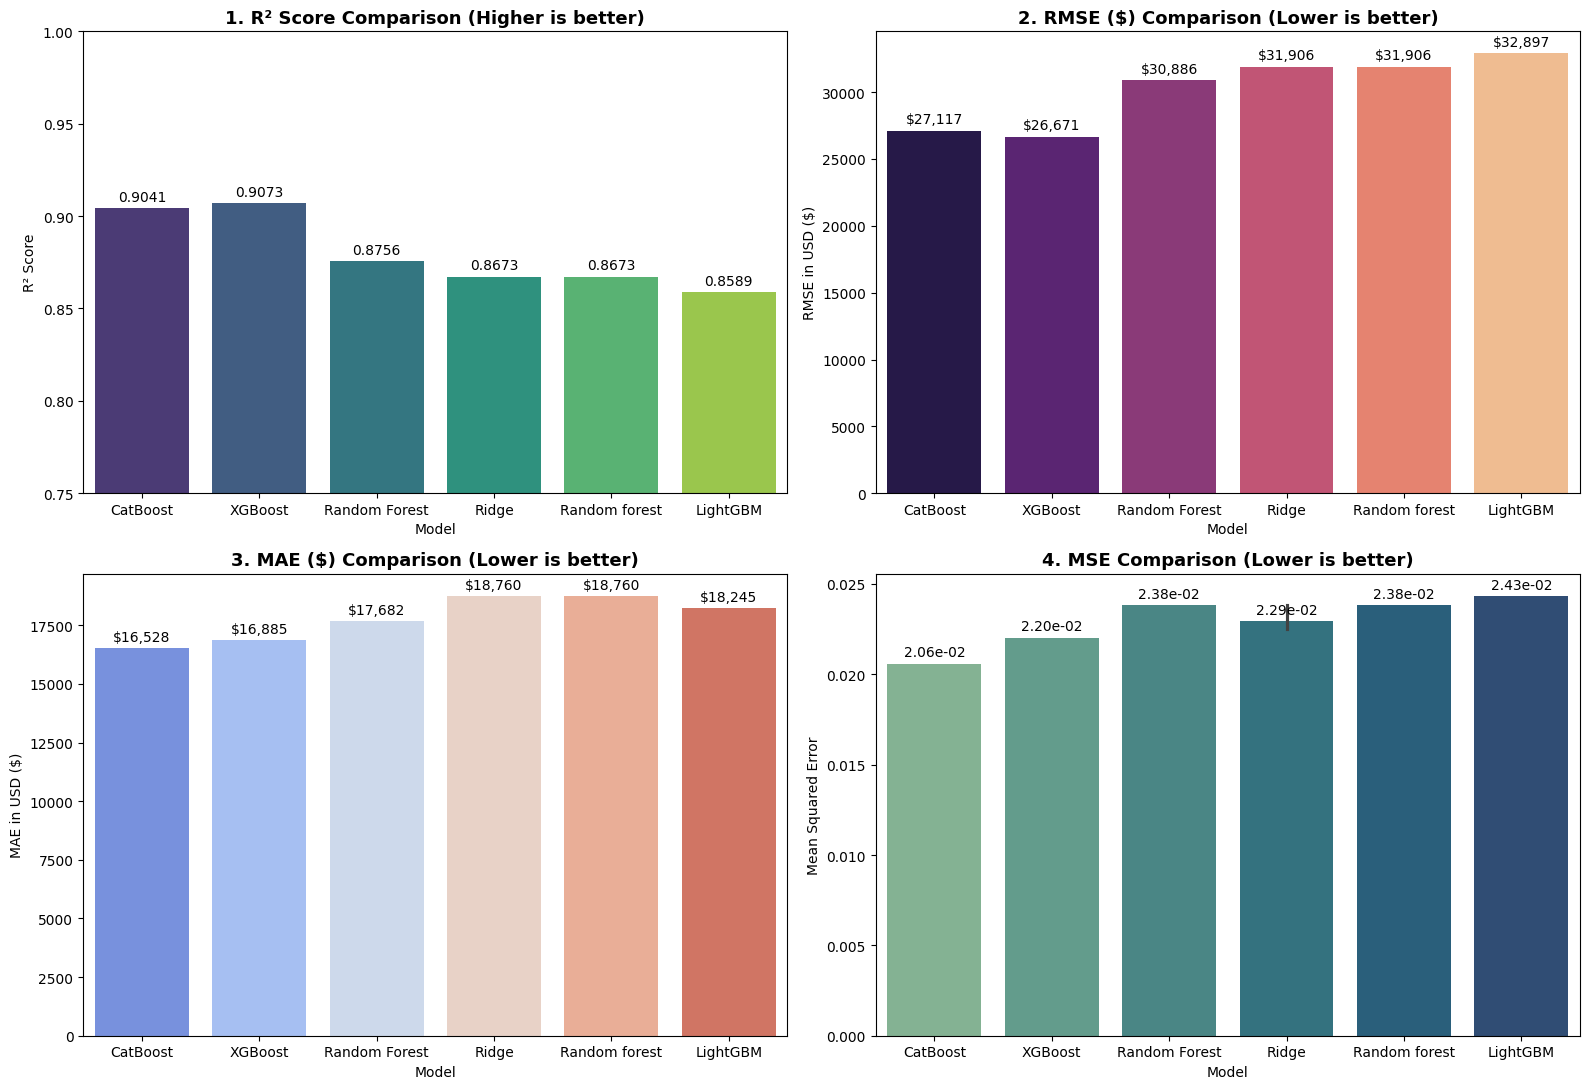

In [68]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. R² Score Plot (Higher is better)

sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('1. R² Score Comparison (Higher is better)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylim(0.75, 1.0)
axes[0, 0].set_ylabel('R² Score')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.4f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')


# 2. RMSE Plot (Lower is better)

sns.barplot(x='Model', y='RMSE ($)', data=results_df, palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('2. RMSE ($) Comparison (Lower is better)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('RMSE in USD ($)')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"${p.get_height():,.0f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')


# 3. MAE Plot (Lower is better)

sns.barplot(x='Model', y='MAE ($)', data=results_df, palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('3. MAE ($) Comparison (Lower is better)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('MAE in USD ($)')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"${p.get_height():,.0f}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')


# 4. MSE Plot (Lower is better)

sns.barplot(x='Model', y='MSE', data=results_df, palette='crest', ax=axes[1, 1])
axes[1, 1].set_title('4. MSE Comparison (Lower is better)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Mean Squared Error')
for p in axes[1, 1].patches:
    
    val = p.get_height()
    axes[1, 1].annotate(f"{val:.2e}", 
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


Save the best model

In [69]:
import os


os.makedirs('models/best_model', exist_ok=True)


best_model = joblib.load(f'models/{best_model_name}_model.joblib')
save_path = f'models/best_model/{best_model_name}.joblib'
joblib.dump(best_model, save_path)

print(f"Saved {best_model_name} as '{save_path}' successfully!")


Saved CatBoost as 'models/best_model/CatBoost.joblib' successfully!
